In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import seaborn as sb
from math import sqrt,pi,exp,ceil
%matplotlib inline



In [2]:
df=pd.read_csv(r'C:\Users\kinni\OneDrive\Desktop\PROJECTS\COLLEGE PROJECT\Heart_Disease_Updated.csv')
df.head()

,Unnamed: 0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target,ca,thal
0,0,0,1,2,100,289,0,0,172,0,0.0,1,0,0,3
1,1,9,0,3,160,180,0,0,156,0,1.0,2,1,0,1
2,2,37,1,2,130,283,0,1,98,0,0.0,1,0,2,3
3,3,8,0,0,138,210,0,0,108,1,1.5,2,1,1,2
4,0,50,1,3,150,195,0,0,122,0,0.0,1,0,0,3


In [3]:
df.isnull().sum()

Unnamed: 0             0
age                    0
sex                    0
chest pain type        0
resting bps            0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
ca                     0
thal                   0
dtype: int64

In [4]:
df.columns

Index(['Unnamed: 0', 'age', 'sex', 'chest pain type', 'resting bps',
       'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate',
       'exercise angina', 'oldpeak', 'ST slope', 'target', 'ca', 'thal'],
      dtype='object')

In [5]:

cols_to_convert = ['age', 'sex', 'chest pain type', 'resting bps', 'cholesterol', 'fasting blood sugar', 'resting ecg',
                   'max heart rate', 'exercise angina', 'ST slope', 'oldpeak', 'ca', 'thal', 'target']
df[cols_to_convert] = df[cols_to_convert].astype(float)


In [6]:
df

,Unnamed: 0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target,ca,thal
0,0,0.0,1.0,2.0,100.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0,0.0,0.0,3.0
1,1,9.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,1.0,0.0,1.0
2,2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0,0.0,2.0,3.0
3,3,8.0,0.0,0.0,138.0,210.0,0.0,0.0,108.0,1.0,1.5,2.0,1.0,1.0,2.0
4,0,50.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1043,297,68.0,0.0,3.0,120.0,211.0,0.0,0.0,115.0,0.0,1.5,1.0,1.0,1.0,3.0
1044,298,0.0,0.0,3.0,108.0,101.0,0.0,1.0,175.0,0.0,0.6,1.0,1.0,3.0,1.0
1045,299,52.0,1.0,1.0,128.0,255.0,0.0,1.0,161.0,1.0,0.0,2.0,0.0,1.0,2.0
1046,300,59.0,1.0,0.0,160.0,273.0,0.0,0.0,125.0,0.0,0.0,2.0,0.0,0.0,1.0


In [7]:
df.dtypes

Unnamed: 0               int64
age                    float64
sex                    float64
chest pain type        float64
resting bps            float64
cholesterol            float64
fasting blood sugar    float64
resting ecg            float64
max heart rate         float64
exercise angina        float64
oldpeak                float64
ST slope               float64
target                 float64
ca                     float64
thal                   float64
dtype: object

In [8]:
df.describe()

,Unnamed: 0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target,ca,thal
count,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000
mean,371.166031,42.775763,0.734733,1.317748,125.449427,236.237595,0.162214,0.606870,136.720420,0.368321,0.854198,1.532443,0.496183,0.934160,1.898855
std,314.468192,23.732437,0.441686,1.206157,20.324853,58.653157,0.368823,0.763313,28.184158,0.482579,1.021685,0.611023,0.500224,1.039091,0.700170
min,0.000000,0.000000,0.000000,0.000000,90.000000,0.000000,0.000000,0.000000,69.000000,0.000000,-0.100000,0.000000,0.000000,0.000000,1.000000
25%,105.000000,9.000000,0.000000,0.000000,110.000000,202.000000,0.000000,0.000000,110.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
50%,231.000000,53.000000,1.000000,1.000000,122.000000,227.500000,0.000000,0.000000,132.500000,0.000000,0.500000,2.000000,0.000000,1.000000,2.000000
75%,657.250000,60.000000,1.000000,2.000000,133.000000,273.000000,0.000000,1.000000,161.000000,1.000000,1.500000,2.000000,1.000000,2.000000,2.000000
max,1189.000000,77.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000,3.000000,3.000000


In [9]:
df.groupby('target').mean()

,Unnamed: 0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,ca,thal
target,,,,,,,,,,,,,,
0.0,359.907197,40.284091,0.685606,1.630682,124.710227,233.102273,0.123106,0.522727,139.835227,0.238636,0.637121,1.227273,0.907197,1.903409
1.0,382.598077,45.305769,0.784615,1.000000,126.200000,239.421154,0.201923,0.692308,133.557692,0.500000,1.074615,1.842308,0.961538,1.894231


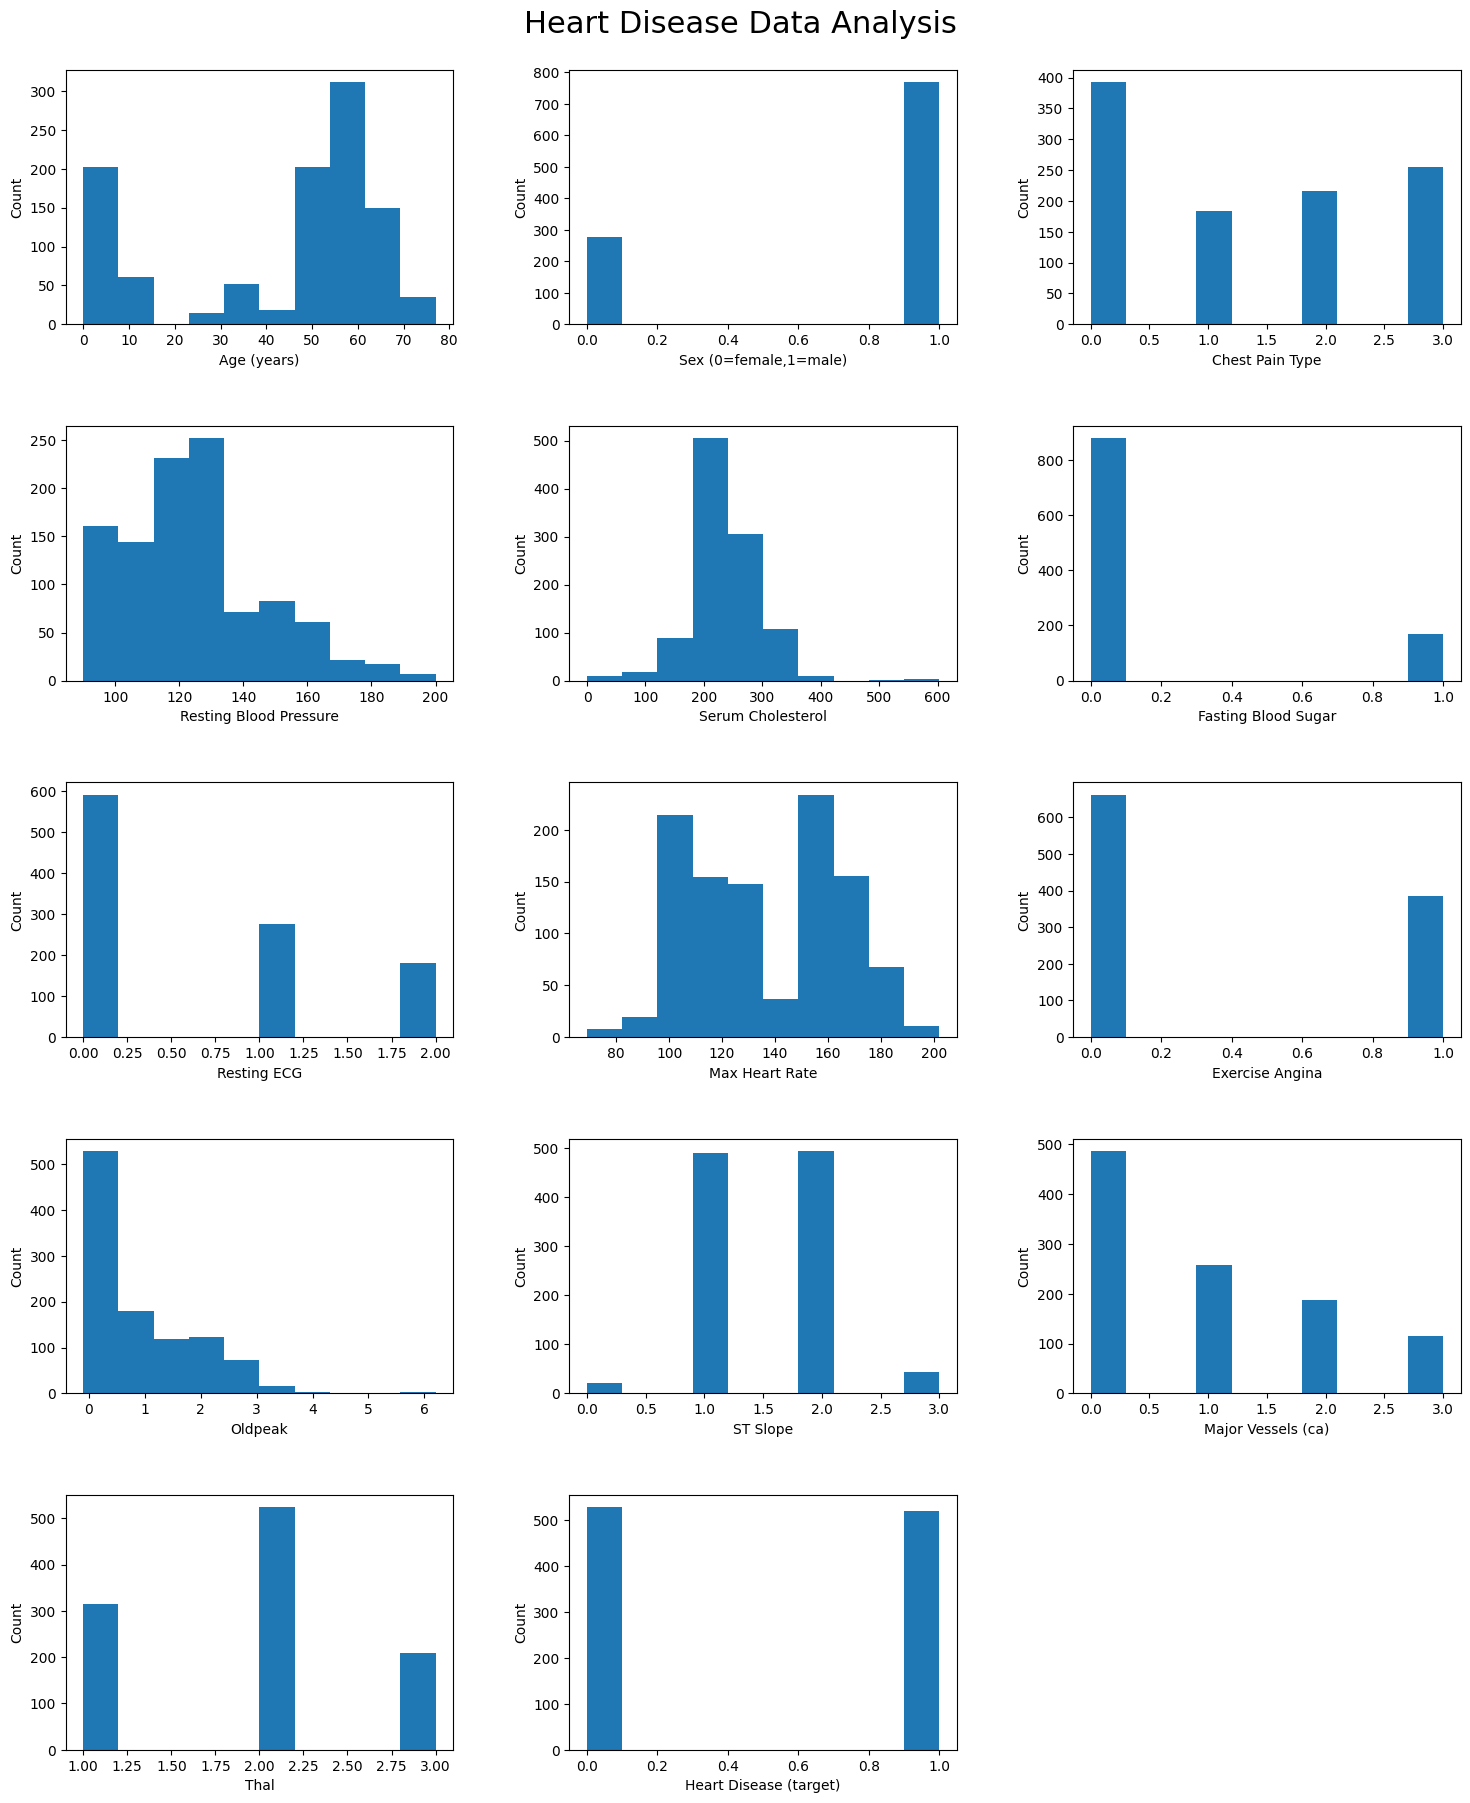

In [10]:
# Clean column names
df.columns = df.columns.str.strip()

# Label pairs: (actual column name, x-axis label)
col_labels = [
    ("age", "Age (years)"),
    ("sex", "Sex (0=female,1=male)"),
    ("chest pain type", "Chest Pain Type"),
    ("resting bps", "Resting Blood Pressure"),
    ("cholesterol", "Serum Cholesterol"),
    ("fasting blood sugar", "Fasting Blood Sugar"),
    ("resting ecg", "Resting ECG"),
    ("max heart rate", "Max Heart Rate"),
    ("exercise angina", "Exercise Angina"),
    ("oldpeak", "Oldpeak"),
    ("ST slope", "ST Slope"),
    ("ca", "Major Vessels (ca)"),
    ("thal", "Thal"),
    ("target", "Heart Disease (target)")
]

# Calculate required number of rows
num_plots = len(col_labels)
cols = 3
rows = int(np.ceil(num_plots / cols))


# Create subplots
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(18, rows * 4))
plt.subplots_adjust(wspace=0.3, hspace=0.4, top=0.95)
plt.suptitle("Heart Disease Data Analysis", fontsize=22)

# Flatten axes array for easier indexing
axes = axes.flatten()

# Plot each column
for i, (col, label) in enumerate(col_labels):
    axes[i].hist(df[col])
    axes[i].set_xlabel(label)
    axes[i].set_ylabel("Count")

# Hide unused subplots
for i in range(num_plots, len(axes)):
    axes[i].axis("off")

plt.show()

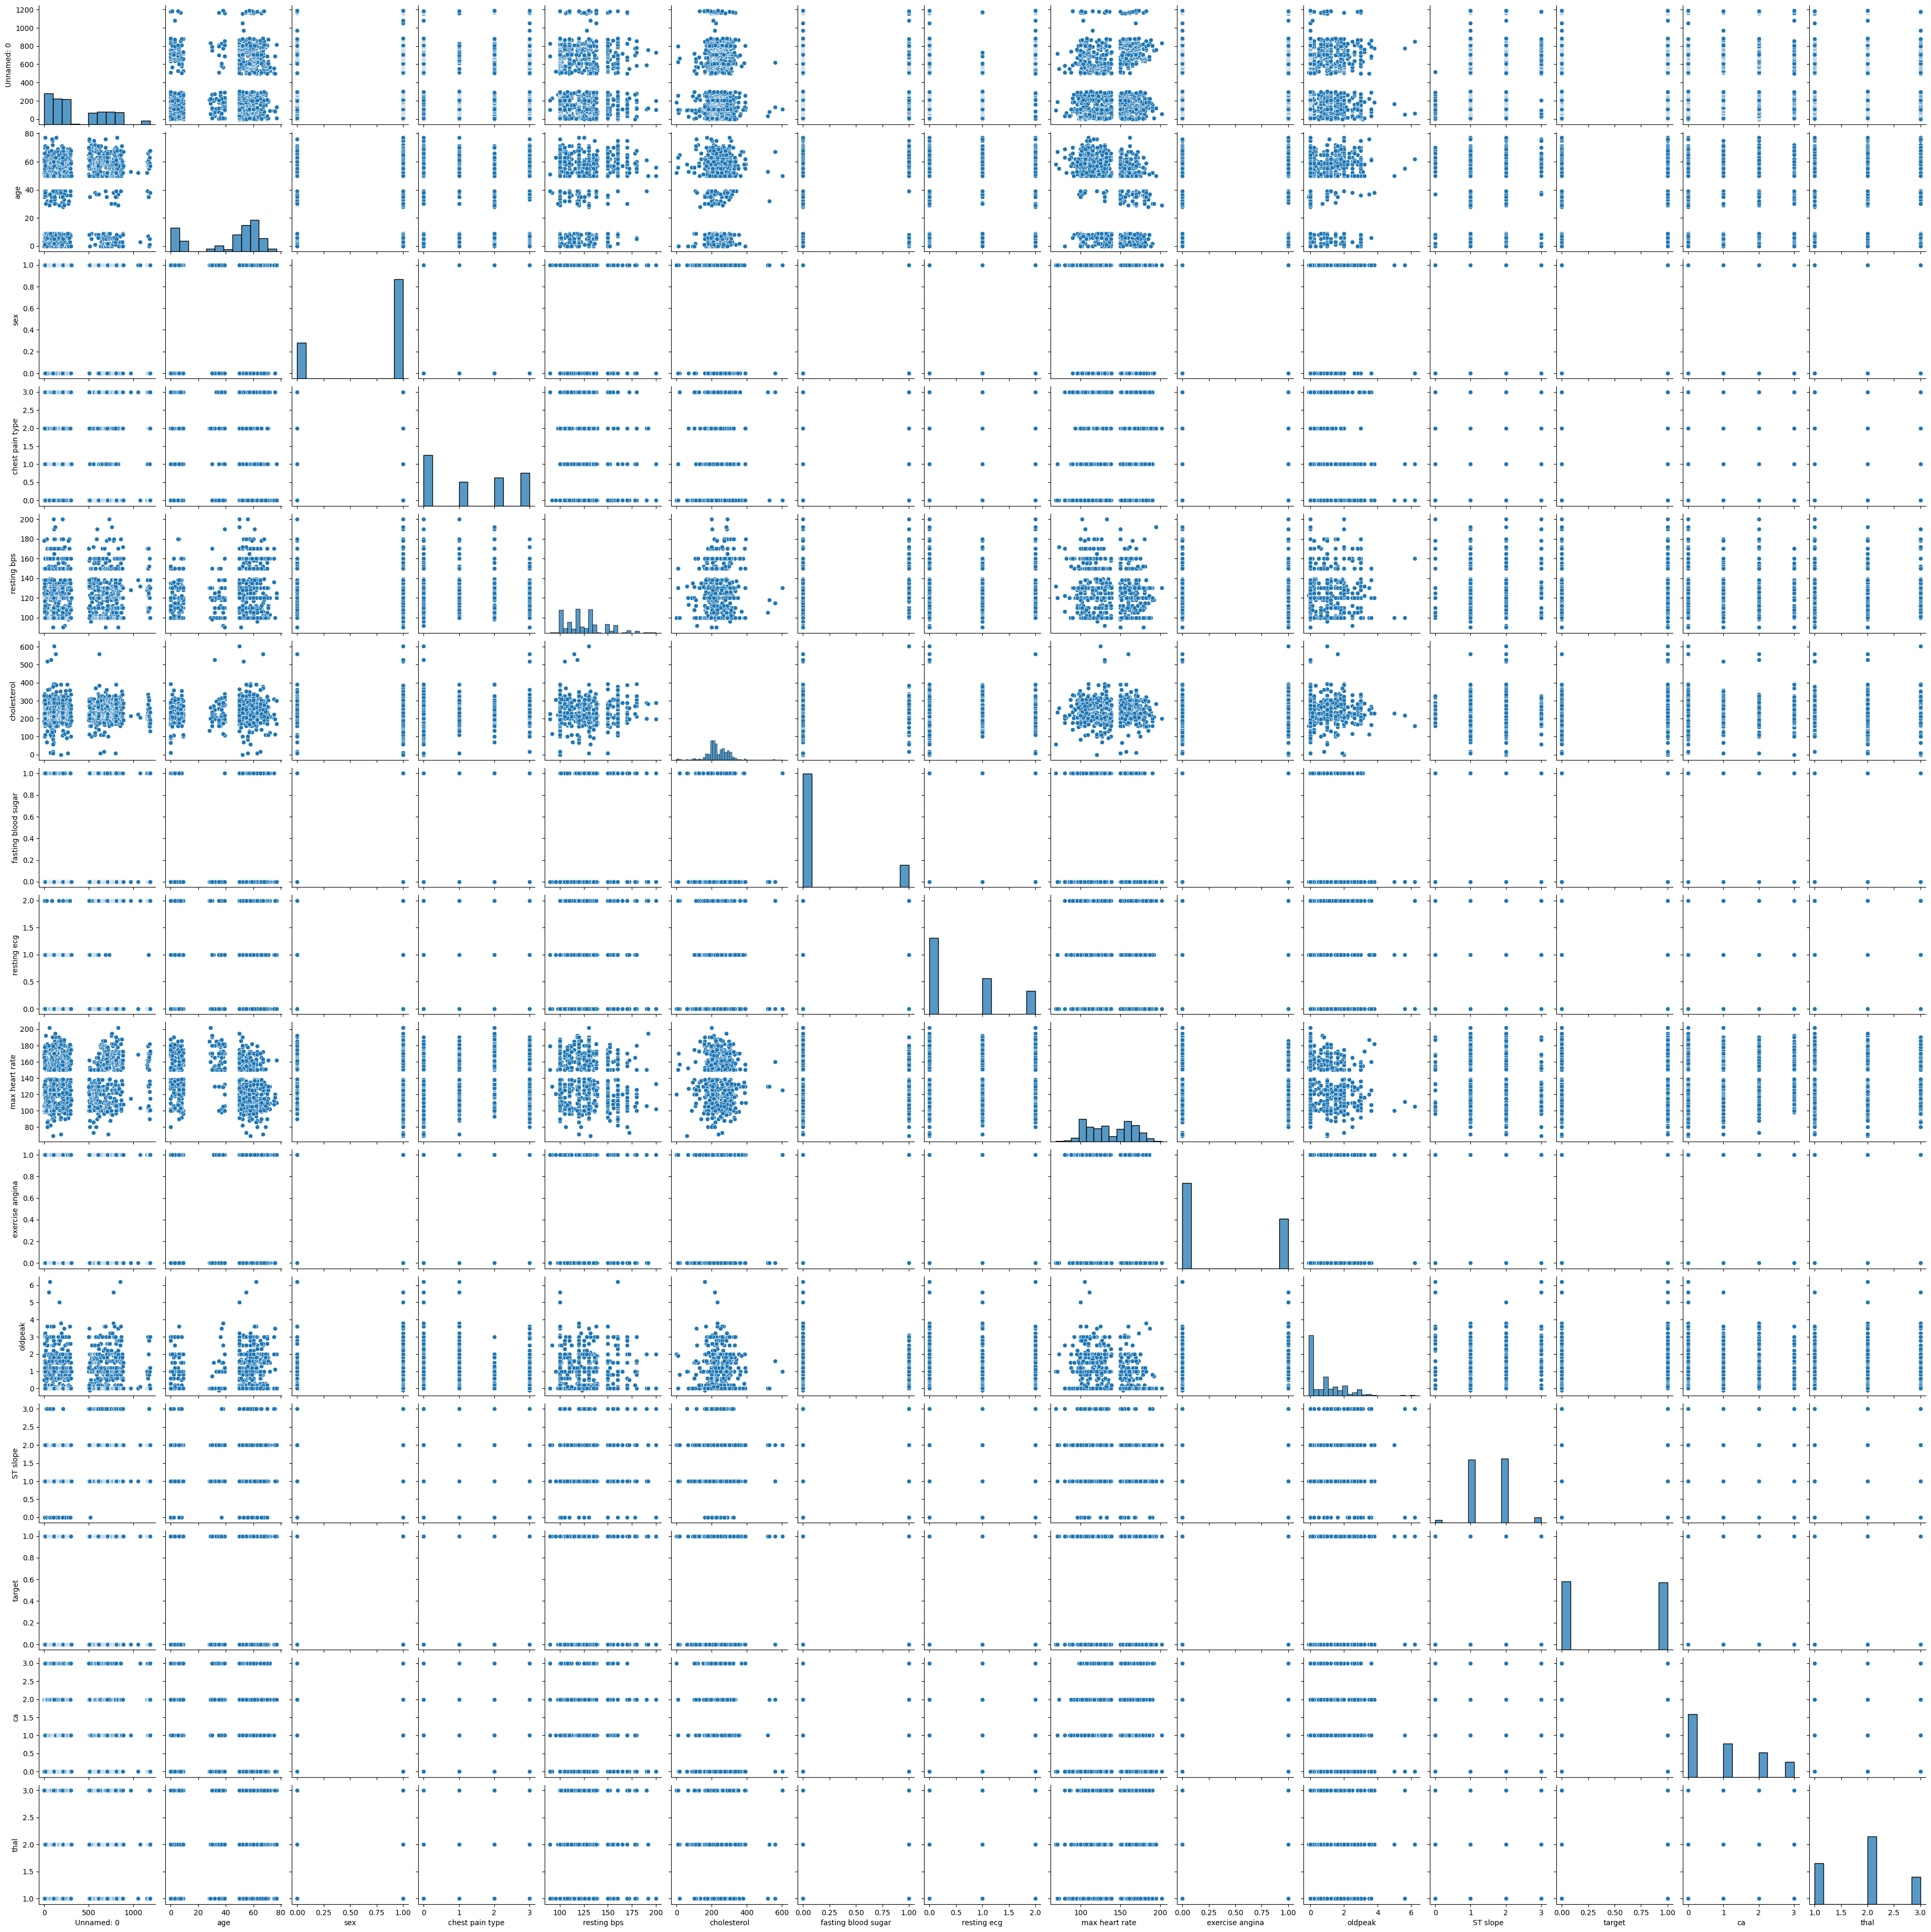

In [11]:
#Correlation Graphs
sb.pairplot(df)
plt.show()

In [12]:
# Filter out invalid age entries (e.g., age < 20 or age > 100)
df = df[(df['age'] >= 20) & (df['age'] <= 100)]

C:\Users\kinni\AppData\Local\Temp\ipykernel_29880\3244380761.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=age_group_labels, y=age_group_counts, palette='viridis')


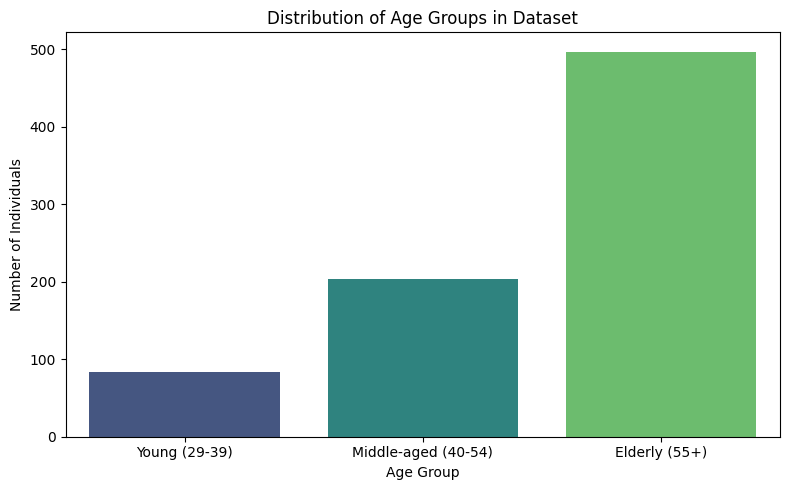

In [13]:
# Define age groups
age_groups = {
    'Young (29-39)': df[(df.age >= 29) & (df.age < 40)],
    'Middle-aged (40-54)': df[(df.age >= 40) & (df.age < 55)],
    'Elderly (55+)': df[df.age >= 55]
}

# Prepare data for visualization
age_group_labels = list(age_groups.keys())
age_group_counts = [len(group) for group in age_groups.values()]

# Bar plot of age group distribution
plt.figure(figsize=(8, 5))
sb.barplot(x=age_group_labels, y=age_group_counts, palette='viridis')
plt.xlabel('Age Group')
plt.ylabel('Number of Individuals')
plt.title('Distribution of Age Groups in Dataset')
plt.tight_layout()
plt.show()


<Figure size 2000x600 with 0 Axes>

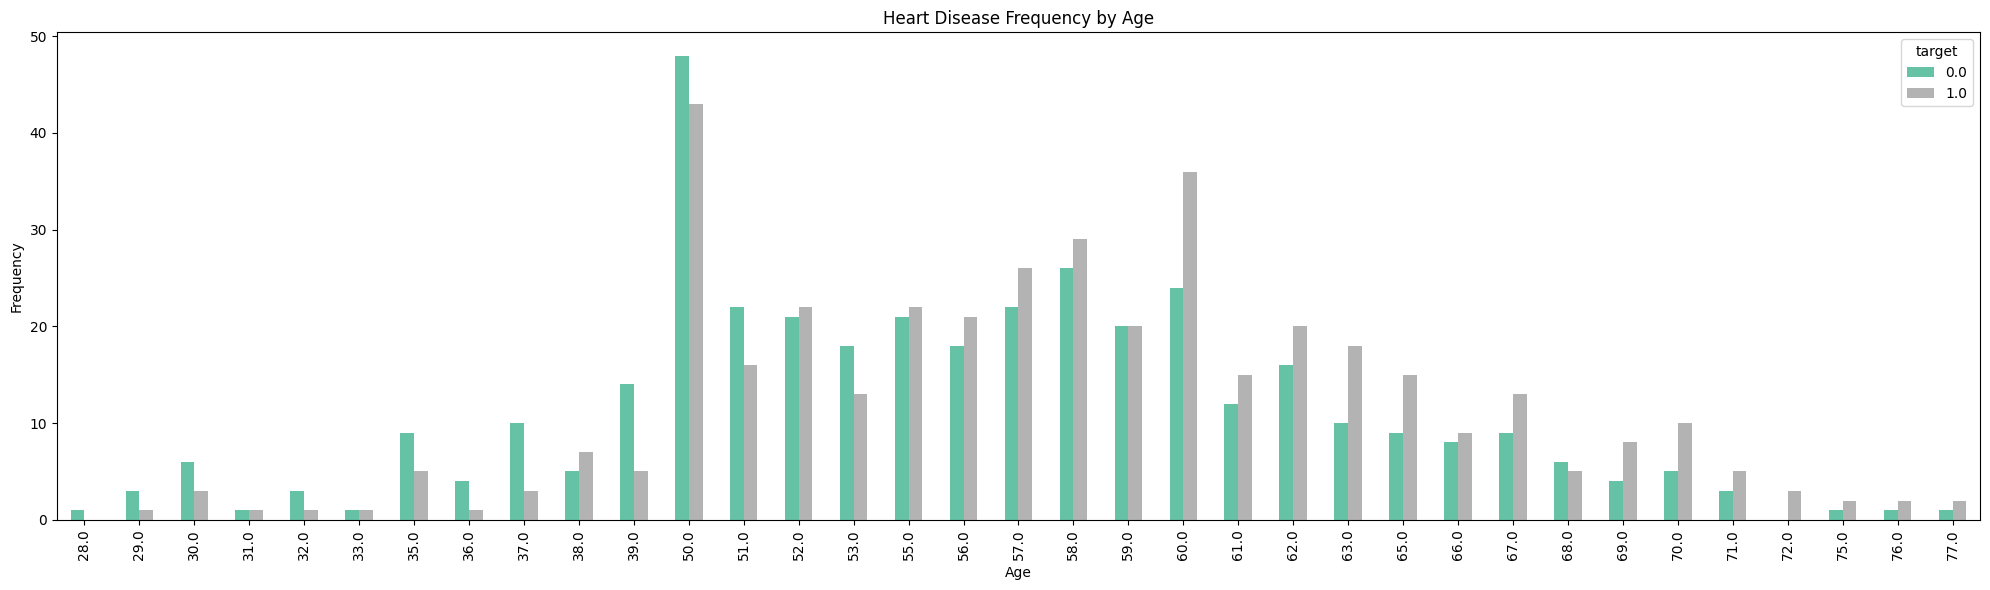

In [14]:
# Cross-tab of age vs. target
plt.figure(figsize=(20, 6))
pd.crosstab(df.age, df.target).plot(kind='bar', figsize=(20, 6), colormap='Set2')
plt.title('Heart Disease Frequency by Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\kinni\AppData\Local\Temp\ipykernel_29880\2896708653.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='sex', data=df, palette='pastel')


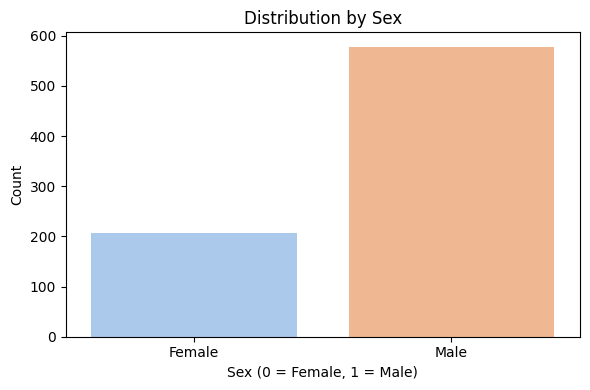

<Figure size 1000x600 with 0 Axes>

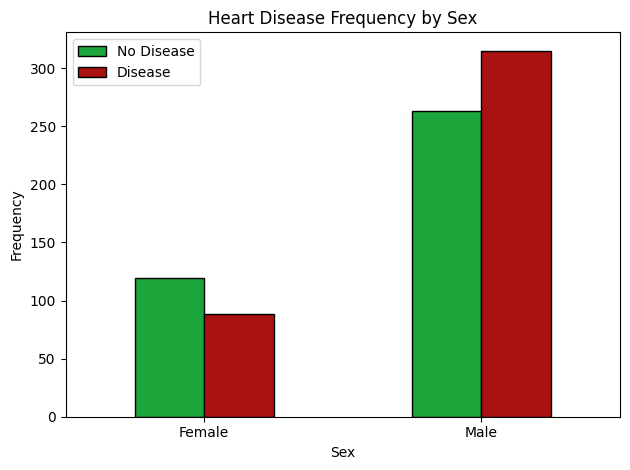

In [15]:

# Count of each sex
plt.figure(figsize=(6, 4))
sb.countplot(x='sex', data=df, palette='pastel')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.title('Distribution by Sex')
plt.xticks([0, 1], ['Female', 'Male'])
plt.tight_layout()
plt.show()

# Heart Disease Frequency by Sex
plt.figure(figsize=(10, 6))
pd.crosstab(df['sex'], df['target']).plot(kind="bar", color=['#1CA53B', '#AA1111'], edgecolor='black')
plt.title('Heart Disease Frequency by Sex')
plt.xlabel('Sex')
plt.ylabel('Frequency')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'], rotation=0)
plt.legend(["No Disease", "Disease"])
plt.tight_layout()
plt.show()

C:\Users\kinni\AppData\Local\Temp\ipykernel_29880\1902758645.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cp_label'] = df['chest pain type'].map(cp_labels)
C:\Users\kinni\AppData\Local\Temp\ipykernel_29880\1902758645.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='cp_label', data=df, palette='Set2', order=cp_labels.values())


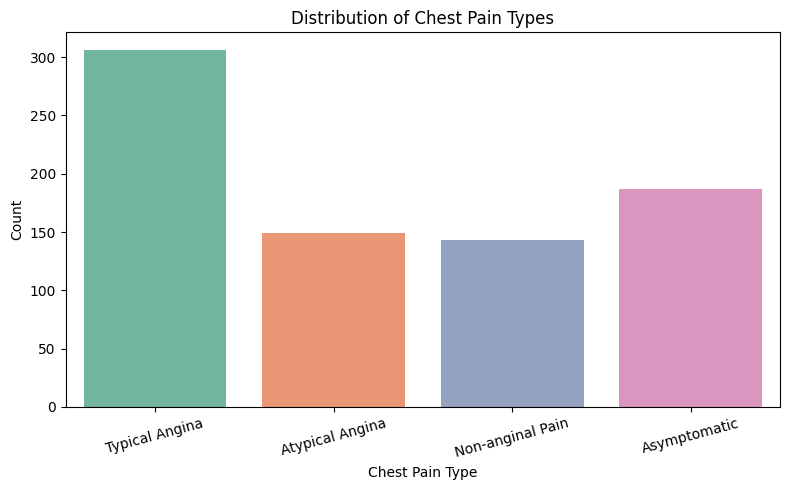

<Figure size 1000x600 with 0 Axes>

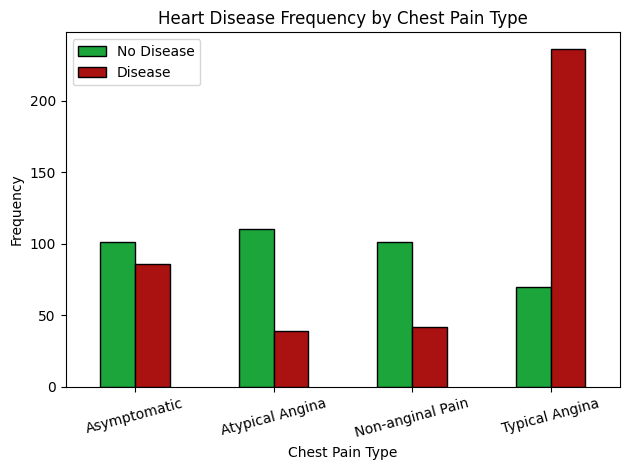

In [16]:
# Map chest pain types to labels for clarity
cp_labels = {
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'Non-anginal Pain',
    3: 'Asymptomatic'
}

df['cp_label'] = df['chest pain type'].map(cp_labels)

# Count plot for chest pain types
plt.figure(figsize=(8, 5))
sb.countplot(x='cp_label', data=df, palette='Set2', order=cp_labels.values())
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.title('Distribution of Chest Pain Types')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Crosstab for chest pain type vs target
plt.figure(figsize=(10, 6))
cp_target_ct = pd.crosstab(df['cp_label'], df['target'])
cp_target_ct.plot(kind='bar', color=['#1CA53B', '#AA1111'], edgecolor='black')
plt.title('Heart Disease Frequency by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Frequency')
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Ideal Blood Pressure: 259
Pre-High Blood Pressure: 365
High Blood Pressure: 161


C:\Users\kinni\AppData\Local\Temp\ipykernel_29880\2439370214.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=['Ideal', 'Pre-High', 'High'], y=[len(ideal_bp), len(pre_high_bp), len(high_bp)], palette='coolwarm')


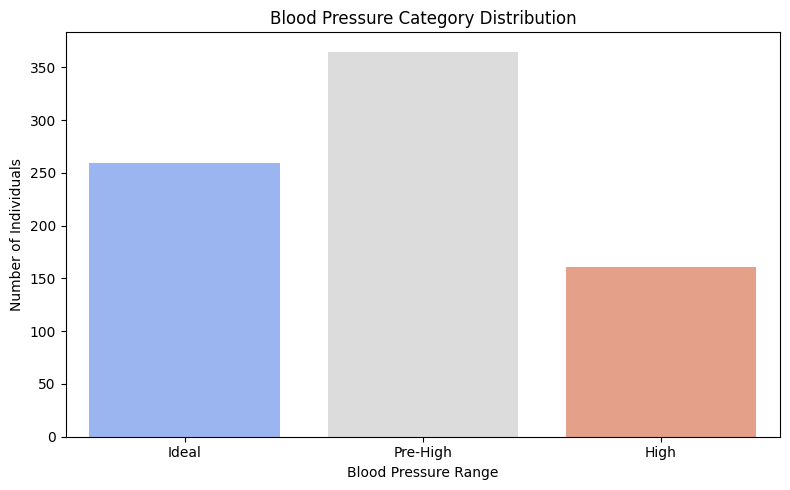

In [17]:
# Filter unrealistic values (optional but good practice)
df = df[(df['resting bps'] >= 70) & (df['resting bps'] <= 250)]

# Categorize blood pressure ranges
ideal_bp = df[(df['resting bps'] >= 90) & (df['resting bps'] < 120)]
pre_high_bp = df[(df['resting bps'] >= 120) & (df['resting bps'] < 140)]
high_bp = df[df['resting bps'] >= 140]

# Print counts
print('Ideal Blood Pressure:', len(ideal_bp))
print('Pre-High Blood Pressure:', len(pre_high_bp))
print('High Blood Pressure:', len(high_bp))

# Barplot: Blood pressure category counts
plt.figure(figsize=(8, 5))
sb.barplot(x=['Ideal', 'Pre-High', 'High'], y=[len(ideal_bp), len(pre_high_bp), len(high_bp)], palette='coolwarm')
plt.xlabel('Blood Pressure Range')
plt.ylabel('Number of Individuals')
plt.title('Blood Pressure Category Distribution')
plt.tight_layout()
plt.show()

<Figure size 2000x600 with 0 Axes>

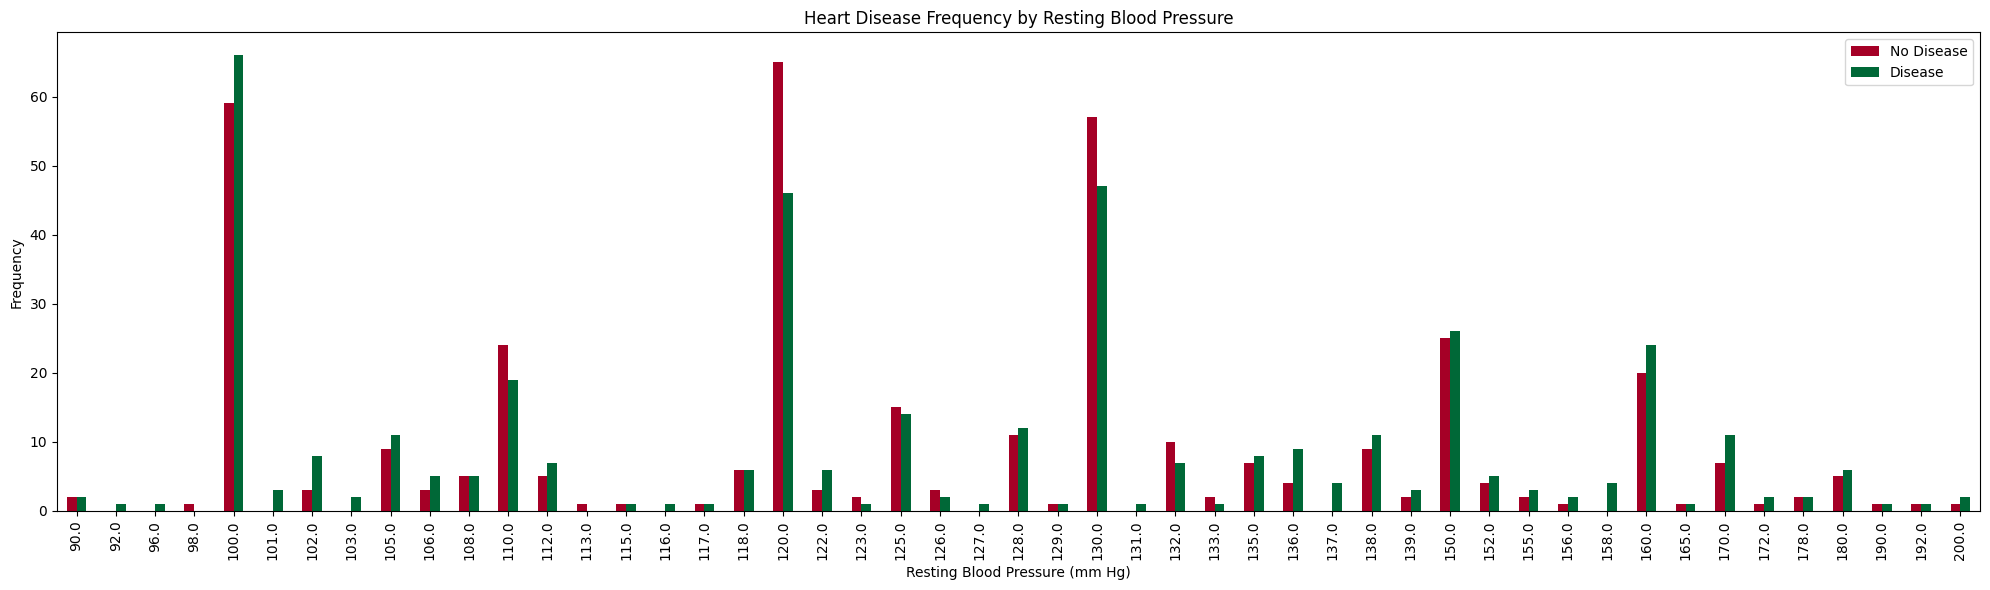

In [18]:
# Bar plot: Heart disease frequency by resting blood pressure
plt.figure(figsize=(20, 6))
pd.crosstab(df['resting bps'], df['target']).plot(kind="bar", stacked=False, figsize=(20, 6), colormap='RdYlGn')
plt.title('Heart Disease Frequency by Resting Blood Pressure')
plt.xlabel('Resting Blood Pressure (mm Hg)')
plt.ylabel('Frequency')
plt.legend(["No Disease", "Disease"])
plt.tight_layout()
plt.show()

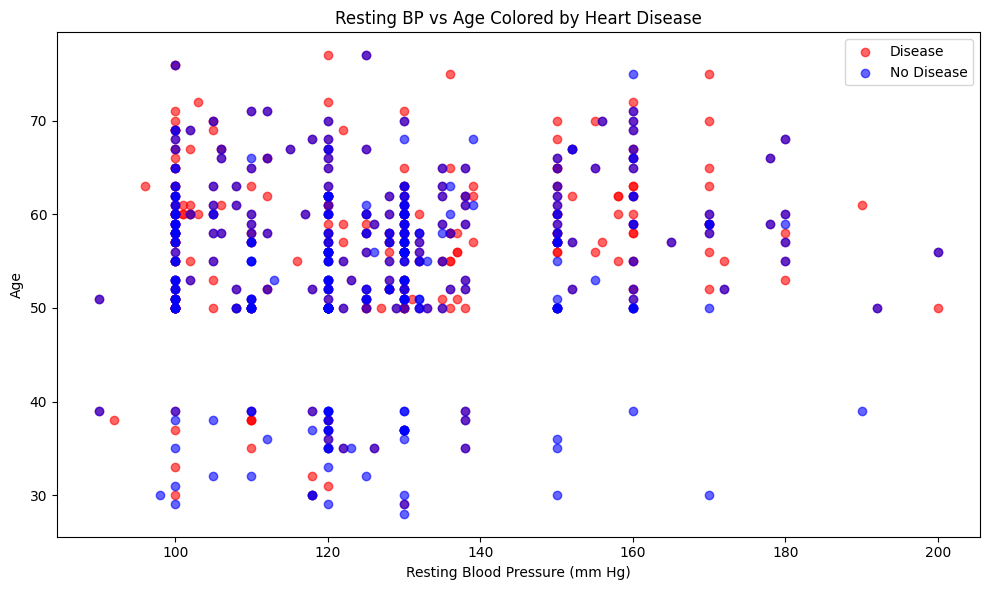

In [19]:
# Scatter plot: Resting blood pressure vs Age for target
plt.figure(figsize=(10, 6))
plt.scatter(df['resting bps'][df.target == 1], df.age[df.target == 1], color='red', alpha=0.6)
plt.scatter(df['resting bps'][df.target == 0], df.age[df.target == 0], color='blue', alpha=0.6)
plt.legend(["Disease", "No Disease"])
plt.xlabel('Resting Blood Pressure (mm Hg)')
plt.ylabel('Age')
plt.title('Resting BP vs Age Colored by Heart Disease')
plt.tight_layout()
plt.show()

In [20]:
# Filter out extreme outliers for better visualization (e.g., chol > 500)
df_filtered = df[(df['cholesterol'] >= 100) & (df['cholesterol'] <= 500)]


<Figure size 2000x600 with 0 Axes>

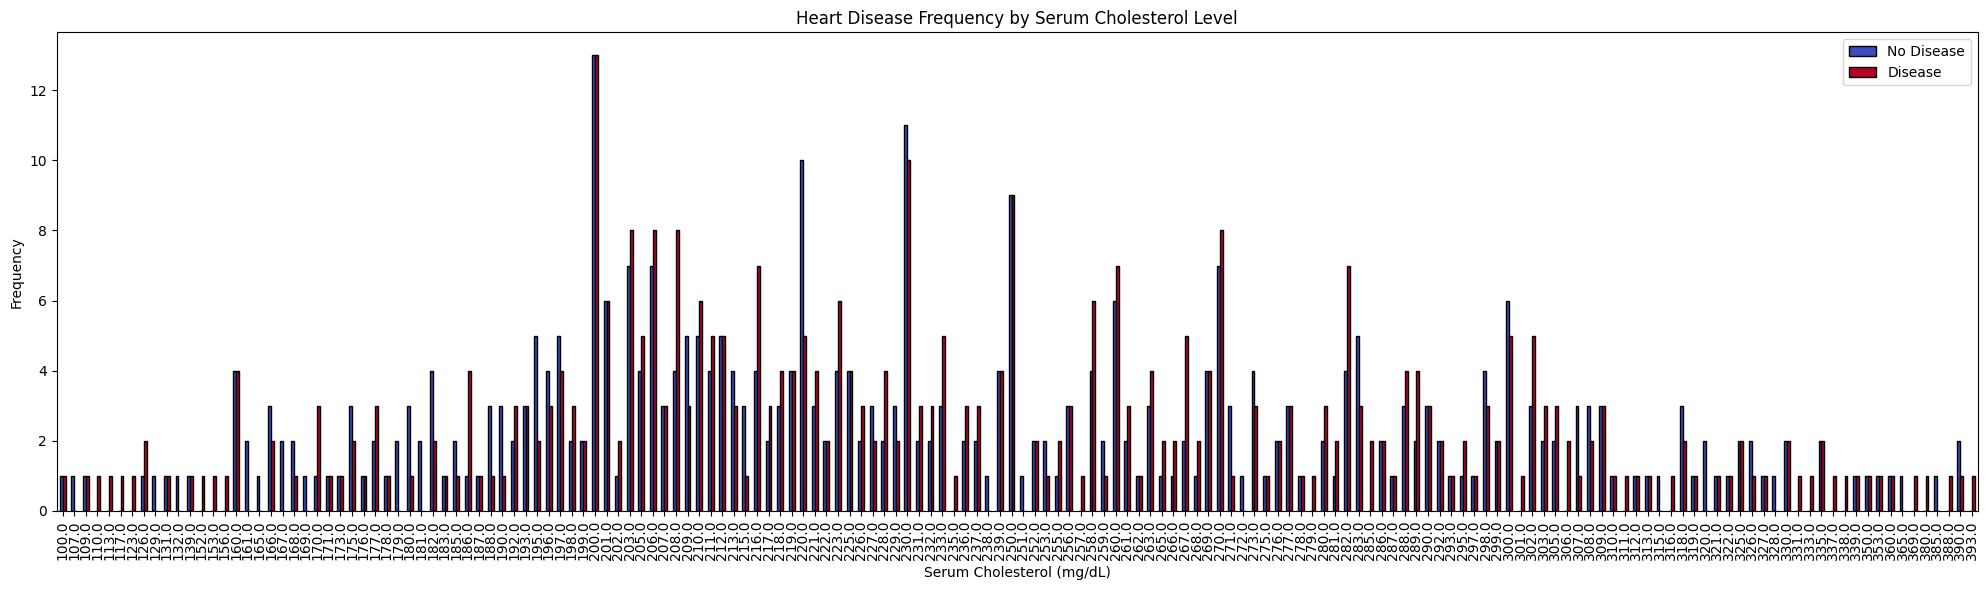

In [21]:
# Bar Plot: Serum Cholesterol vs Heart Disease
plt.figure(figsize=(20, 6))
pd.crosstab(df_filtered['cholesterol'], df_filtered['target']).plot(
    kind="bar", figsize=(20, 6), stacked=False, colormap="coolwarm", edgecolor='black')
plt.title('Heart Disease Frequency by Serum Cholesterol Level')
plt.xlabel('Serum Cholesterol (mg/dL)')
plt.ylabel('Frequency')
plt.legend(["No Disease", "Disease"])
plt.tight_layout()
plt.show()

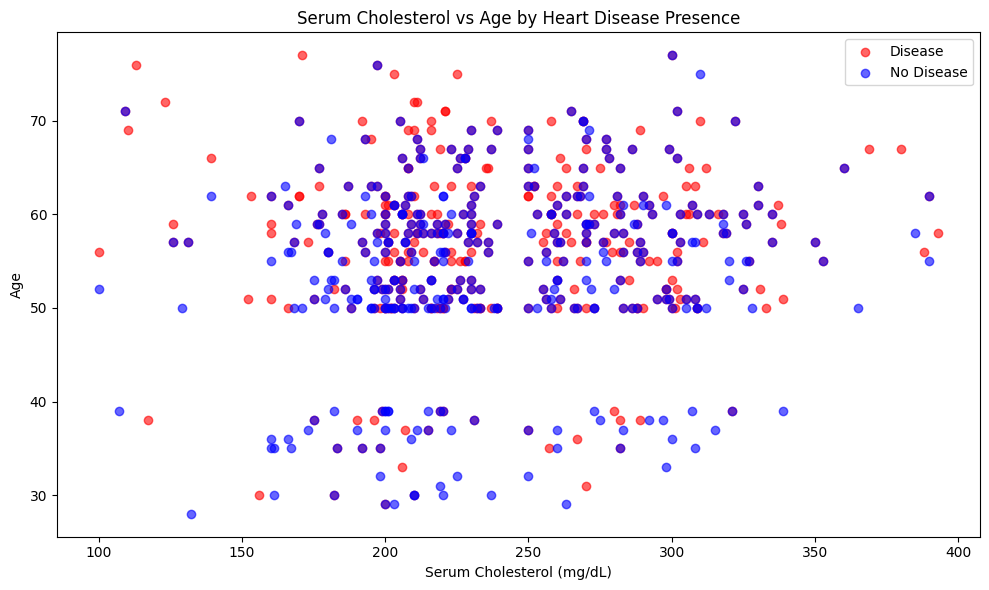

In [22]:
# Scatter Plot: Serum Cholesterol vs Age for Target
plt.figure(figsize=(10, 6))
plt.scatter(df_filtered['cholesterol'][df_filtered.target == 1],
            df_filtered['age'][df_filtered.target == 1],
            color='red', alpha=0.6, label='Disease')

plt.scatter(df_filtered['cholesterol'][df_filtered.target == 0],
            df_filtered['age'][df_filtered.target == 0],
            color='blue', alpha=0.6, label='No Disease')
plt.xlabel('Serum Cholesterol (mg/dL)')
plt.ylabel('Age')
plt.title('Serum Cholesterol vs Age by Heart Disease Presence')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Map fbs values to readable labels (0 = <120 mg/dL, 1 = ≥120 mg/dL)
fbs_labels = {0: '< 120 mg/dL', 1: '≥ 120 mg/dL'}
df['fbs_label'] = df['fasting blood sugar'].map(fbs_labels)


<Figure size 800x500 with 0 Axes>

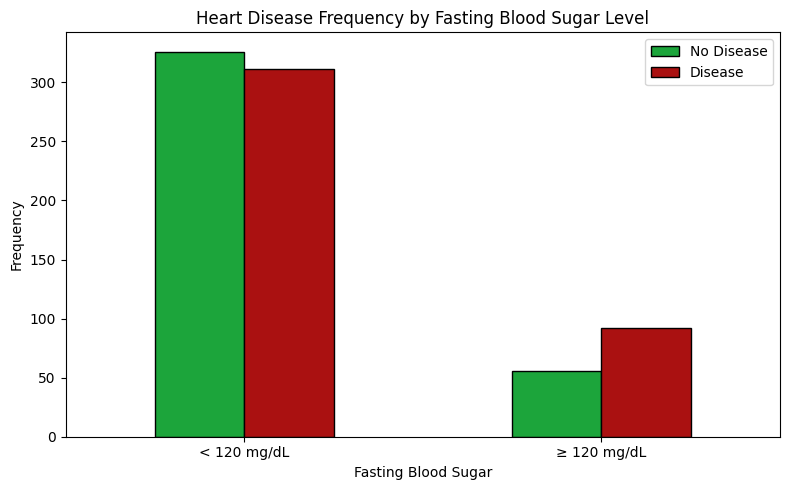

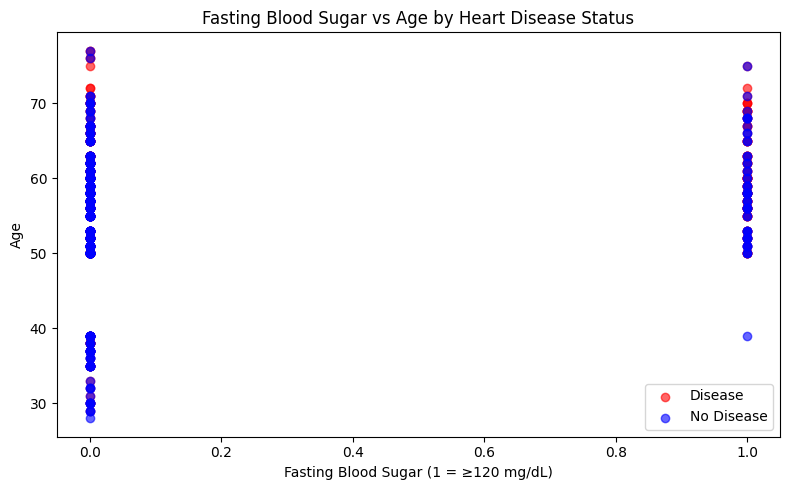

In [24]:
# Bar Plot: Fasting Blood Sugar vs Target
plt.figure(figsize=(8, 5))
pd.crosstab(df['fbs_label'], df['target']).plot(
    kind="bar", figsize=(8, 5), color=['#1CA53B', '#AA1111'], edgecolor='black')
plt.title('Heart Disease Frequency by Fasting Blood Sugar Level')
plt.xlabel('Fasting Blood Sugar')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.legend(["No Disease", "Disease"])
plt.tight_layout()
plt.show()

# Scatter Plot: Fasting Blood Sugar vs Age by Target
plt.figure(figsize=(8, 5))
plt.scatter(df['fasting blood sugar'][df.target == 1], df.age[df.target == 1], c="red", label='Disease', alpha=0.6)
plt.scatter(df['fasting blood sugar'][df.target == 0], df.age[df.target == 0], c="blue", label='No Disease', alpha=0.6)
plt.xlabel("Fasting Blood Sugar (1 = ≥120 mg/dL)")
plt.ylabel("Age")
plt.title("Fasting Blood Sugar vs Age by Heart Disease Status")
plt.legend()
plt.tight_layout()
plt.show()

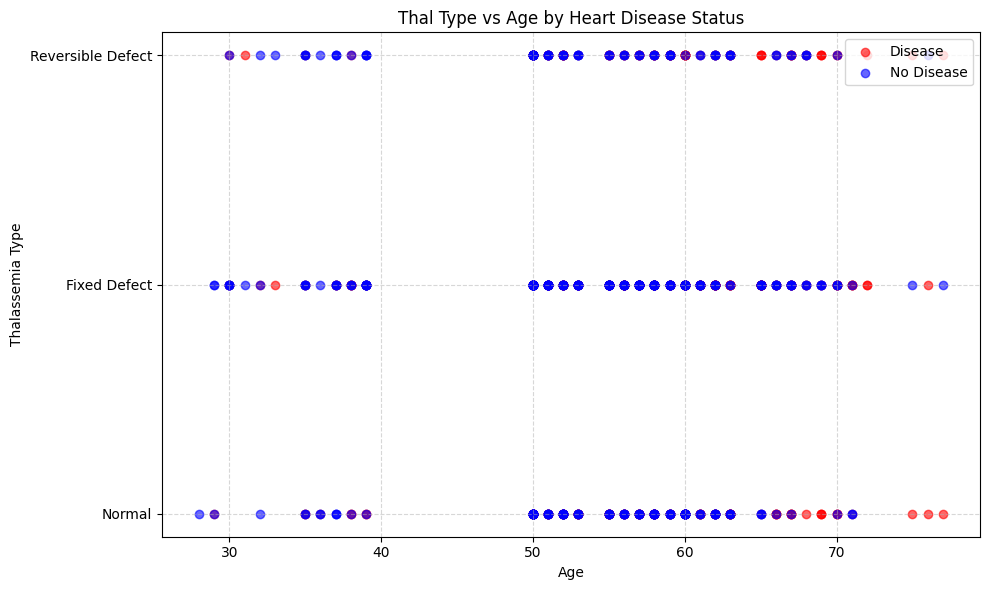

In [25]:
# Map thal values to labels
thal_labels = {1: 'Normal', 2: 'Fixed Defect', 3: 'Reversible Defect'}
df['thal_label'] = df['thal'].map(thal_labels)

# Scatter plot: Age vs Thal type (colored by target)
plt.figure(figsize=(10, 6))

# Plot for people with heart disease
plt.scatter(df.age[df.target == 1], df.thal[df.target == 1],
            color='red', label='Disease', alpha=0.6)

# Plot for people without heart disease
plt.scatter(df.age[df.target == 0], df.thal[df.target == 0],
            color='blue', label='No Disease', alpha=0.6)

plt.yticks([1, 2, 3], ['Normal', 'Fixed Defect', 'Reversible Defect'])
plt.xlabel("Age")
plt.ylabel("Thalassemia Type")
plt.title("Thal Type vs Age by Heart Disease Status")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

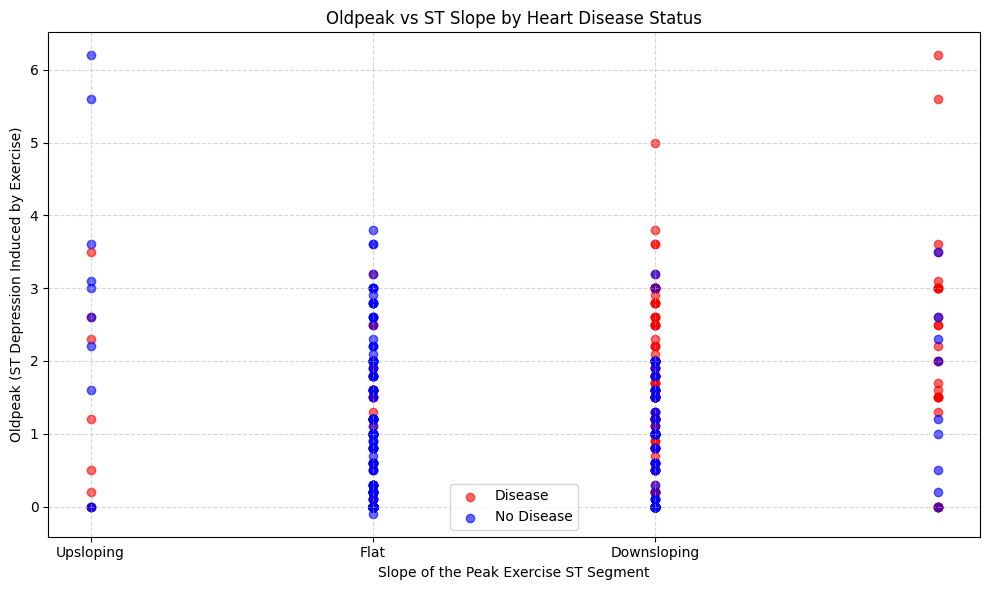

In [26]:
# Optional: Map slope values to readable labels
slope_labels = {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'}
df['slope_label'] = df['ST slope'].map(slope_labels)

# Scatter Plot: Oldpeak vs ST slope by Heart Disease
plt.figure(figsize=(10, 6))

# Plot for patients with heart disease
plt.scatter(df['ST slope'][df.target == 1], df.oldpeak[df.target == 1],
            color='red', label='Disease', alpha=0.6)

# Plot for patients without heart disease
plt.scatter(df['ST slope'][df.target == 0], df.oldpeak[df.target == 0],
            color='blue', label='No Disease', alpha=0.6)

plt.xticks([0, 1, 2], ['Upsloping', 'Flat', 'Downsloping'])
plt.xlabel("Slope of the Peak Exercise ST Segment")
plt.ylabel("Oldpeak (ST Depression Induced by Exercise)")
plt.title("Oldpeak vs ST Slope by Heart Disease Status")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()